# Gemini 멀티모달 입력

이미지, PDF, 음성, 동영상과 텍스트를 함께 전달하고 Gemini가 여러 형태의 입력을 이해하는 과정을 확인합니다. 작은 파일은 Base64로 직접 전달하고, 다시 사용할 파일은 Files API에 업로드합니다.

### 실행 환경 준비

In [1]:
import base64
import mimetypes
import os
from pathlib import Path

from dotenv import load_dotenv
from google import genai
from IPython.display import Image, display

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError(".env 파일에 GEMINI_API_KEY를 설정해 주세요.")

model = os.getenv("GEMINI_MODEL", "gemini-3.6-flash")
client = genai.Client(api_key=api_key)
print("준비 완료 / 사용 모델:", model)

준비 완료 / 사용 모델: gemini-3.6-flash


### 파일 입력 방법 비교

| 방법 | 전달 값 | 적합한 상황 |
| --- | --- | --- |
| Base64 | `data` | 작고 한 번만 사용할 파일 |
| Files API | `uri` | 크거나 여러 요청에서 재사용할 파일 |
| 공개 URL | `uri` | 인터넷에서 바로 접근할 수 있는 파일 |


### 로컬 이미지를 Base64로 전달하기

작은 로컬 이미지는 파일을 읽어 Base64 문자열로 변환한 뒤 `data`에 넣을 수 있습니다. 노트북과 같은 폴더에 분석할 이미지를 `sample.jpg`라는 이름으로 저장합니다.

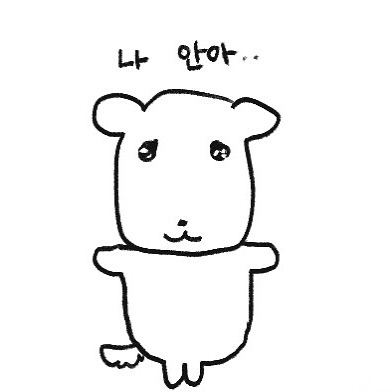

In [4]:
image_path = Path("sample.jpg")
if not image_path.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path.resolve()}")

mime_type, _ = mimetypes.guess_type(image_path)
if mime_type not in {"image/jpeg", "image/png", "image/webp"}:
    raise ValueError("JPG, PNG 또는 WebP 이미지를 사용해 주세요.")

display(Image(filename=str(image_path), width=500))

In [5]:
image_data = base64.b64encode(image_path.read_bytes()).decode("utf-8")

local_interaction = client.interactions.create(
    model=model,
    input=[
        {
            "type": "image",
            "data": image_data,
            "mime_type": mime_type,
        },
        {
            "type": "text",
            "text": "이 이미지에 무엇이 보이는지 설명해 줘.",
        },
    ],
    store=False,
)

print(local_interaction.output_text)

이미지에는 검은색 선으로 단순하고 귀엽게 그려진 손그림 캐릭터가 담겨 있습니다. 주요 요소는 다음과 같습니다:

1. **캐릭터 모습**: 곰이나 햄스터를 닮은 동물이 양팔을 옆으로 넓게 벌리고 서 있습니다.
2. **표정**: 눈물이 글썽이는 듯 촉촉하고 큰 눈망울을 하고 있어 어리광을 부리거나 위로를 바라는 듯한 느낌을 줍니다.
3. **텍스트**: 머리 위에 **"나 안아.."**라는 한글 문구가 적혀 있습니다.

전체적으로 상대방에게 안아달라고 애교를 부리거나 위로를 받고 싶어 하는 귀여운 짤(이모티콘) 이미지입니다.


### Files API로 이미지 전달하기

이미지를 Files API에 업로드한 뒤 발급받은 파일 URI를 `uri`에 지정합니다. 파일 업로드와 모델 요청은 서로 다른 작업이므로, 업로드한 파일 하나를 여러 질문에서 재사용할 수 있습니다.

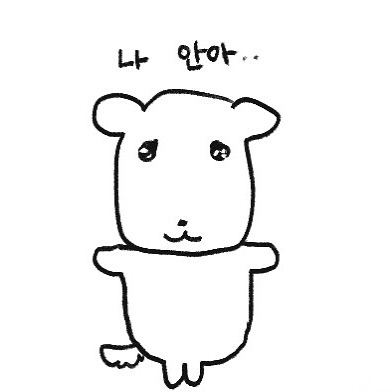

이 이미지에는 다음과 같은 내용이 담겨 있습니다:

1. **캐릭터 (손그림 동물):**
   * 검은색 선으로 단순하게 그려진 귀여운 동물(곰이나 강아지 모양) 캐릭터가 있습니다.
   * 초롱초롱하고 반짝이는 눈으로 바라보며, 양팔을 넓게 벌리고 서 있는 모습입니다.
   * 상대방에게 안겨서 위로받고 싶어 하거나 애교를 부리는 듯한 표정을 짓고 있습니다.

2. **텍스트:**
   * 캐릭터 머리 위에 손글씨로 **"나 안아.."**라는 한글 문구가 적혀 있습니다.

전체적으로 누군가에게 관심이나 애정, 혹은 따뜻한 포옹을 원할 때 귀엽게 마음을 표현하는 짤(이모티콘) 이미지입니다.


In [6]:
image_path = Path("sample.jpg")
if not image_path.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path.resolve()}")

display(Image(filename=str(image_path), width=500))
uploaded_file = client.files.upload(file=str(image_path))

url_interaction = client.interactions.create(
    model=model,
    input=[
        {
            "type": "image",
            "uri": uploaded_file.uri,
            "mime_type": uploaded_file.mime_type,
        },
        {
            "type": "text",
            "text": "이 이미지에 무엇이 보이는지 설명해 줘.",
        },
    ],
    store=False,
)

print(url_interaction.output_text)

### PDF·음성·동영상 업로드하기

Files API의 업로드 방법은 파일 종류와 관계없이 같습니다. 차이는 모델 입력에 지정하는 `type`입니다.

In [ ]:
def input_type_from_mime(mime_type: str) -> str:
    if mime_type.startswith("image/"):
        return "image"
    if mime_type.startswith("audio/"):
        return "audio"
    if mime_type.startswith("video/"):
        return "video"
    return "document"


def analyze_file(file_path: str, prompt: str):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path.resolve()}")

    uploaded = client.files.upload(file=str(path))
    input_type = input_type_from_mime(uploaded.mime_type)

    interaction = client.interactions.create(
        model=model,
        input=[
            {
                "type": input_type,
                "uri": uploaded.uri,
                "mime_type": uploaded.mime_type,
            },
            {"type": "text", "text": prompt},
        ],
        store=False,
    )
    return uploaded, interaction

In [ ]:
uploaded_file, file_result = analyze_file(
    "sample.pdf",
    "문서의 핵심 내용을 세 문장으로 요약하고, 주요 일정을 표로 정리해 줘.",
)

print(file_result.output_text)

### 업로드한 파일 확인하기

`files.get()`으로 업로드된 파일의 URI, MIME type과 처리 상태를 다시 확인할 수 있습니다.

In [ ]:
file_metadata = client.files.get(name=uploaded_file.name)
print("이름:", file_metadata.name)
print("URI:", file_metadata.uri)
print("MIME type:", file_metadata.mime_type)
print("상태:", file_metadata.state.name if file_metadata.state else "상태 정보 없음")

### 이미지 생성하기

이미지 생성 모델에 장면을 설명하면 결과가 Base64 이미지로 반환됩니다. 생성된 이미지를 파일로 저장한 뒤 노트북에서 확인합니다.

In [ ]:
image_model = os.getenv("GEMINI_IMAGE_MODEL", "gemini-3.1-flash-image")
prompt = "따뜻한 오후 햇살이 비치는 책상 위의 노트북과 커피잔을 수채화 스타일로 그려 줘."

image_interaction = client.interactions.create(
    model=image_model,
    input=prompt,
    response_format={
        "type": "image",
        "mime_type": "image/jpeg",
        "aspect_ratio": "16:9",
    },
)

generated_path = Path("generated_image.jpg")
generated_path.write_bytes(
    base64.b64decode(image_interaction.output_image.data)
)

display(Image(filename=str(generated_path), width=700))

### 실습 문제

PDF, 음성 또는 동영상 중 하나를 선택해 다음 작업을 수행하세요.

- Files API로 파일을 업로드합니다.
- 파일 처리가 끝날 때까지 상태를 확인합니다.
- 파일 종류에 맞는 질문을 전달합니다.
- 같은 업로드 파일에 서로 다른 질문을 한 번 더 전달합니다.
- 두 응답의 입력·출력 토큰을 확인합니다.